# ASQA black-box RAGAS feature notebook

Notebook này tạo feature table theo từng sample từ `labeled_asqa.csv`, chỉ dùng các metric black-box của RAGAS khi **không có ground truth**, sau đó train một dãy classifier từ cơ bản đến mạnh hơn.

Output chính:
- `results/asqa_ragas_blackbox_features.csv`
- bảng so sánh các mô hình classifier
- model tốt nhất được lưu ra disk để dùng lại

## Imports and setup

In [1]:
from __future__ import annotations

import ast
import importlib
import importlib.util
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from dotenv import load_dotenv
import os

load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
HUGGINGFACE_API_KEY = os.getenv("HUGGINGFACE_API_KEY")
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")


XGBOOST_AVAILABLE = importlib.util.find_spec("xgboost") is not None
XGBClassifier = importlib.import_module("xgboost").XGBClassifier if XGBOOST_AVAILABLE else None

sys.path.append('..')

DATA_PATH = Path('../data/asqa/labeled_asqa.csv')
OUTPUT_DIR = Path('../results')
MODEL_DIR = Path('../models/ragas_filter')
FEATURE_PATH = OUTPUT_DIR / "asqa_ragas_features.csv"

import src.filtering.ragas as _ragas_mod
importlib.reload(_ragas_mod)
from src.filtering.ragas import RAGAS, CheckpointedEvaluationResult

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)
np.random.seed(42)

print(f"DATA_PATH = {DATA_PATH}")
print(f"XGBOOST_AVAILABLE = {XGBOOST_AVAILABLE}")

c:\Users\vnpq2\anaconda3\envs\ragas-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DATA_PATH = ..\data\asqa\labeled_asqa.csv
XGBOOST_AVAILABLE = True


## Helper functions

In [2]:
def _safe_literal_eval(raw_value):
    if raw_value is None or (isinstance(raw_value, float) and np.isnan(raw_value)):
        return None
    if isinstance(raw_value, (dict, list)):
        return raw_value
    if not isinstance(raw_value, str):
        return raw_value
    cleaned = raw_value.replace('""', '"')
    try:
        return ast.literal_eval(cleaned)
    except Exception:
        return raw_value


def parse_supporting_facts(supporting_facts_raw, context_raw):
    try:
        # ===== clean string =====
        sf_clean = supporting_facts_raw.replace('""', '"')
        ctx_clean = context_raw.replace('""', '"')

        sf = ast.literal_eval(sf_clean)
        ctx = ast.literal_eval(ctx_clean)

        # ===== lấy danh sách title cần dùng =====
        sf_titles = set(sf.get("title", []))

        ctx_titles = ctx.get("title", [])
        ctx_sentences = ctx.get("sentences", [])

        facts = []

        # ===== lọc đúng doc theo title =====
        for title, sents in zip(ctx_titles, ctx_sentences):
            if title in sf_titles or str(title).startswith("QA"):
                joined_sents = " ".join(sents)

                facts.append(f"- ({title}) {joined_sents}")

        return "\n".join(facts)

    except Exception:
        return ""


def extract_ragas_contexts(supporting_facts_raw, context_raw):
    extracted = parse_supporting_facts(supporting_facts_raw, context_raw)
    if extracted:
        return [line[2:].strip() for line in extracted.splitlines() if line.strip()]

    ctx = _safe_literal_eval(context_raw)
    if isinstance(ctx, dict):
        titles = ctx.get("title", [])
        sentences = ctx.get("sentences", [])
        fallback = []
        for title, sents in zip(titles, sentences):
            if sents:
                fallback.append(f"({title}) {' '.join(sents)}")
        return fallback

    return []

## Imports data and initialize evaluator

In [3]:
df = pd.read_csv(DATA_PATH)
df["label"] = df["label"].astype(int)

expected_columns = {"id", "question", "answer", "context", "supporting_facts", "label"}
missing_columns = expected_columns - set(df.columns)
if missing_columns:
    raise ValueError(f"Missing columns in CSV: {sorted(missing_columns)}")

df["ragas_contexts"] = df.apply(
    lambda row: extract_ragas_contexts(row["supporting_facts"], row["context"]),
    axis=1,
)
df["ragas_context_count"] = df["ragas_contexts"].apply(len)

print(df.shape)
display(df[["id", "question", "label", "ragas_context_count"]].head())
print(df["label"].value_counts(dropna=False).sort_index())

(8706, 8)


,id,question,label,ragas_context_count
0,asqa_0,When does the new bunk'd come out?,1,4
1,asqa_1,Who won the 2016 ncaa football national championship?,1,3
2,asqa_2,When was the last time the death penalty was used in pa?,1,3
3,asqa_3,Where will failure of the left ventricle cause increased pressure?,1,3
4,asqa_4,Who won the war between ethiopia and italy?,1,4


label
0    4353
1    4353
Name: count, dtype: int64


## RAGAs feature extraction

In [6]:
# Black-box RAGAS metrics: no ground-truth dependent scores
# We intentionally skip answer_correctness / answer_similarity.
metric_names = [
    "faithfulness",
    "answer_relevancy",
    "context_relevancy",
]

evaluator = RAGAS(
    metrics=metric_names,

    # OpenAI models
    llm_model="gpt-4o-mini",
    embedding_model="text-embedding-3-small",

    # optional
    api_key=OPENAI_API_KEY,

    # optional
    temperature=0,
)


ragas_result = evaluator.evaluate_checkpoint(
    questions=df["question"].tolist(),
    answers=df["answer"].tolist(),
    contexts=df["ragas_contexts"].tolist(),
    batch_size=25,
    save_path=Path(OUTPUT_DIR) / "asqa_ragas_checkpoints.csv",
    show_progress=True,
)

ragas_scores_df = ragas_result.to_pandas()
ragas_scores_df = ragas_scores_df[[col for col in metric_names if col in ragas_scores_df.columns]].copy()
ragas_scores_df = ragas_scores_df.reset_index(drop=True)

print(ragas_scores_df.head())
print(ragas_scores_df.describe().T)

Resuming from sample 8706
   faithfulness  answer_relevancy  context_relevancy
0      0.666667          0.726235           0.090909
1      1.000000          0.957490           0.111111
2      1.000000          0.965820           0.111111
3      1.000000          0.641608           0.125000
4      1.000000          0.800938           0.214286
                    count      mean       std  min       25%       50%       75%  max
faithfulness       8706.0  0.698412  0.327578  0.0  0.500000  0.800000  1.000000  1.0
answer_relevancy   8706.0  0.737265  0.208051  0.0  0.675609  0.790222  0.870178  1.0
context_relevancy  8706.0  0.170983  0.123773  0.0  0.090909  0.125000  0.222222  1.0


Save to CSV for training filter model

In [7]:
feature_df = pd.concat(
    [
        df[["id", "label"]].reset_index(drop=True),
        ragas_scores_df.reset_index(drop=True),
    ],
    axis=1,
)

feature_df = feature_df.drop_duplicates(subset=["id"]).reset_index(drop=True)
feature_df.to_csv(FEATURE_PATH, index=False)

print(f"Saved feature table to: {FEATURE_PATH}")
print(feature_df.info())
display(feature_df.head())

Saved feature table to: ..\results\asqa_ragas_features.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8706 entries, 0 to 8705
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8706 non-null   object 
 1   label              8706 non-null   int32  
 2   faithfulness       8706 non-null   float64
 3   answer_relevancy   8706 non-null   float64
 4   context_relevancy  8706 non-null   float64
dtypes: float64(3), int32(1), object(1)
memory usage: 306.2+ KB
None


,id,label,faithfulness,answer_relevancy,context_relevancy
0,asqa_0,1,0.666667,0.726235,0.090909
1,asqa_1,1,1.000000,0.957490,0.111111
2,asqa_2,1,1.000000,0.965820,0.111111
3,asqa_3,1,1.000000,0.641608,0.125000
4,asqa_4,1,1.000000,0.800938,0.214286


## Filter Models Training

Load features and labels

In [9]:
feature_df = pd.read_csv(FEATURE_PATH)
print(feature_df.shape)

(8706, 5)


Data splitting

In [10]:
feature_cols = [col for col in feature_df.columns if col not in {"id", "label"}]
X = feature_df[feature_cols].copy()
y = feature_df["label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

Model training:
- Logistic Regression
- Random Forest
- Gradient Boosting
- HistGradient Boosting
- Extra Trees
- XGBoost *(if available)*


In [11]:
models = {
    "logistic_regression": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
        ]
    ),
    "random_forest": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=400,
                max_depth=None,
                random_state=42,
                class_weight="balanced_subsample",
                n_jobs=-1,
            )),
        ]
    ),
    "gradient_boosting": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", GradientBoostingClassifier(random_state=42)),
        ]
    ),
    "hist_gradient_boosting": HistGradientBoostingClassifier(
        learning_rate=0.08,
        max_iter=300,
        max_leaf_nodes=31,
        random_state=42,
    ),
    "extra_trees": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", ExtraTreesClassifier(
                n_estimators=500,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1,
            )),
        ]
    ),
}

if XGBOOST_AVAILABLE:
    models["xgboost"] = XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
        missing=np.nan,
    )

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")
print(f"Features: {feature_cols}")
print(f"Models: {list(models.keys())}")

Train size: 6964 | Test size: 1742
Features: ['faithfulness', 'answer_relevancy', 'context_relevancy']
Models: ['logistic_regression', 'random_forest', 'gradient_boosting', 'hist_gradient_boosting', 'extra_trees', 'xgboost']


Evaluate and compare models, save results to CSV

In [12]:
def evaluate_classifier(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    metrics = {
        "accuracy": accuracy_score(y_test, predictions),
        "precision": precision_score(y_test, predictions, zero_division=0),
        "recall": recall_score(y_test, predictions, zero_division=0),
        "f1": f1_score(y_test, predictions, zero_division=0),
    }

    if hasattr(model, "predict_proba"):
        try:
            probabilities = model.predict_proba(X_test)[:, 1]
            metrics["roc_auc"] = roc_auc_score(y_test, probabilities)
        except Exception:
            metrics["roc_auc"] = np.nan
    else:
        metrics["roc_auc"] = np.nan

    return metrics, predictions


results = []
trained_models = {}

for name, model in models.items():
    metrics, _ = evaluate_classifier(model, X_train, X_test, y_train, y_test)
    results.append({"model": name, **metrics})
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values(["f1", "accuracy"], ascending=False).reset_index(drop=True)
display(results_df)

best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]
print(f"Best model: {best_model_name}")

,model,accuracy,precision,recall,f1,roc_auc
0,gradient_boosting,0.900115,0.922424,0.873708,0.897406,0.961624
1,xgboost,0.890930,0.912727,0.864524,0.887972,0.960813
2,hist_gradient_boosting,0.877727,0.888889,0.863375,0.875946,0.953798
3,random_forest,0.872560,0.884935,0.856487,0.870478,0.946578
4,extra_trees,0.870838,0.888221,0.848450,0.867880,0.922074
5,logistic_regression,0.787600,0.764520,0.831228,0.796480,0.883097


Best model: gradient_boosting


In [13]:
import joblib

MODEL_DIR.mkdir(parents=True, exist_ok=True)
best_model_path = MODEL_DIR / f"{best_model_name}.joblib"
joblib.dump(best_model, best_model_path)

print(f"Saved best model to: {best_model_path}")

final_predictions = best_model.predict(X_test)
print(classification_report(y_test, final_predictions, zero_division=0))

Saved best model to: ../models/ragas_filter/gradient_boosting.joblib
              precision    recall  f1-score   support

           0       0.88      0.93      0.90       871
           1       0.92      0.87      0.90       871

    accuracy                           0.90      1742
   macro avg       0.90      0.90      0.90      1742
weighted avg       0.90      0.90      0.90      1742



Best model: Gradient Boosting Classifier.

Try to find feature importance from the best model.

In [14]:
def unwrap_estimator(model):
    if hasattr(model, "named_steps"):
        # lấy step cuối trong Pipeline
        return list(model.named_steps.values())[-1]
    return model


def get_feature_importance(model, feature_cols):
    clf = unwrap_estimator(model)

    if not hasattr(clf, "feature_importances_"):
        raise ValueError(f"{type(clf)} không có feature_importances_")

    importance_df = (
        pd.DataFrame({
            "feature": feature_cols,
            "importance": clf.feature_importances_,
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    importance_df["importance_pct"] = (
        importance_df["importance"] / importance_df["importance"].sum()
    )

    return importance_df

In [15]:
# load model from disk
# get model from the only .joblib file in the model directory
model_files = list(MODEL_DIR.glob("*.joblib"))

best_model = joblib.load(model_files[0])
importance_df = get_feature_importance(best_model, feature_cols)
display(importance_df)

,feature,importance,importance_pct
0,faithfulness,0.890460,0.890460
1,context_relevancy,0.099246,0.099246
2,answer_relevancy,0.010294,0.010294


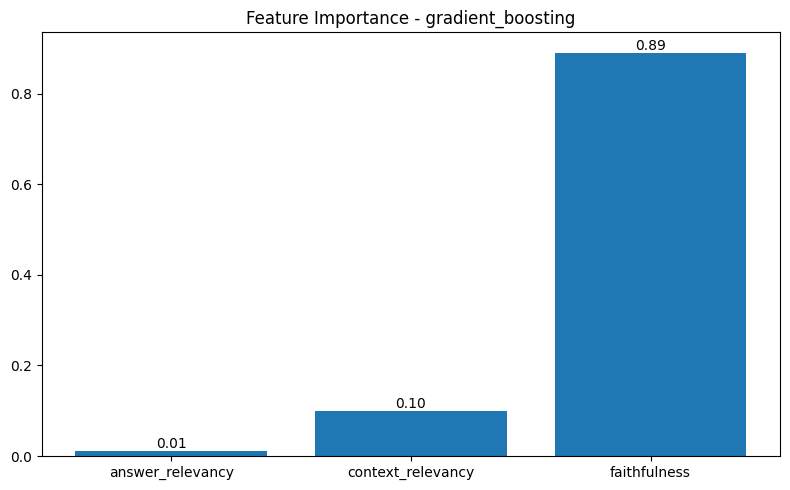

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(
    importance_df["feature"][::-1],
    importance_df["importance"][::-1],
)
importances = importance_df["importance"].values
for i, (feature, importance) in enumerate(zip(importance_df["feature"][::-1], importance_df["importance"][::-1])):
    plt.text(i, importance, f"{importance:.2f}", ha="center", va="bottom")
plt.title(f"Feature Importance - {best_model_name}")
plt.tight_layout()
plt.show()

## Full Filter Pipeline: Evaluate on Normal RAG Predictions

End-to-end pipeline: tính RAGAS black-box metrics, áp dụng filter, so sánh traditional metrics baseline vs. accepted samples.

In [ ]:
# ============================================================
# END-TO-END FILTER EVALUATION PIPELINE
# ============================================================
%load_ext autoreload
%autoreload 2

from __future__ import annotations

import ast
import json
import re
from pathlib import Path

import importlib
import sys
import os

import joblib
import pandas as pd
sys.path.append("..")

from src.evaluation.evaluator import TraditionalEvaluator

import src.filtering.ragas as _ragas_mod
importlib.reload(_ragas_mod)
from src.filtering.ragas import RAGAS

import openai
from dotenv import load_dotenv

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

# ============================================================
# HELPERS
# ============================================================

def _safe_parse_contexts(ctx_raw):

    try:
        if isinstance(ctx_raw, str):
            return ast.literal_eval(ctx_raw)

        if isinstance(ctx_raw, list):
            return ctx_raw

    except Exception:
        pass

    return []


def _normalize_answer(answer: str) -> str:

    answer = str(answer).lower()

    answer = re.sub(r"\b(a|an|the)\b", " ", answer)
    answer = re.sub(r"[^\w\s]", "", answer)

    return " ".join(answer.split())


def exact_match(prediction: str, ground_truth: str) -> float:

    return float(
        _normalize_answer(prediction)
        == _normalize_answer(ground_truth)
    )


def token_f1(prediction: str, ground_truth: str) -> float:

    pred_tokens = _normalize_answer(prediction).split()
    gold_tokens = _normalize_answer(ground_truth).split()

    common = set(pred_tokens) & set(gold_tokens)

    if len(common) == 0:
        return 0.0

    precision = len(common) / max(len(pred_tokens), 1)
    recall = len(common) / max(len(gold_tokens), 1)

    return (
        2 * precision * recall
        / (precision + recall + 1e-8)
    )


# ============================================================
# FILTER PIPELINE
# ============================================================

class FilterPipeline:
    """
    End-to-end RAG answer quality filter evaluation pipeline.

    Input:
        CSV with columns:
        [
            id,
            question,
            gold_answer,
            predicted_answer,
            contexts,
            num_contexts
        ]

    Flow:
        1. Compute RAGAS black-box metrics
        2. Load trained filter model
        3. Apply filter -> accept/reject
        4. Save predictions with labels
        5. Compute traditional metrics
        6. Compare baseline vs filtered
        7. Save comparison log to JSON
    """

    def __init__(
        self,
        csv_path: str | Path,
        ragas_evaluator: RAGAS,
        model_path: str | Path,
        ragas_checkpoint_path: str | Path = None,
        batch_size: int = None,
        output_dir: str | Path = "./results"
    ):

        self.csv_path = Path(csv_path)

        self.model_path = Path(model_path)

        self.ragas_checkpoint_path = Path(ragas_checkpoint_path) if ragas_checkpoint_path else None

        self.output_dir = Path(output_dir)
        self.output_dir.mkdir(parents=True, exist_ok=True)

        self.ragas_evaluator = ragas_evaluator

        self.ragas_batch = batch_size if batch_size else 50

        self.df = None
        self.ragas_df = None
        self.filter_df = None
        self.metric_df = None

    

    # ========================================================
    # LOAD DATA
    # ========================================================

    def load_data(self):

        self.df = pd.read_csv(self.csv_path)

        required_cols = [
            "id",
            "question",
            "gold_answer",
            "predicted_answer",
            "contexts"
        ]

        missing = [
            c for c in required_cols
            if c not in self.df.columns
        ]

        if missing:
            raise ValueError(f"Missing columns: {missing}")

        return self.df

    # ========================================================
    # RAGAS METRICS
    # ========================================================

    def compute_ragas_metrics(self):

        print("\n[1] Computing RAGAS metrics...")

        contexts = []

        for ctx in self.df["contexts"]:

            parsed = _safe_parse_contexts(ctx)

            contexts.append(parsed)

        if self.ragas_checkpoint_path:
            ragas_result = self.ragas_evaluator.evaluate_checkpoint(
                questions=self.df["question"].tolist(),
                answers=self.df["predicted_answer"].tolist(),
                contexts=contexts,
                batch_size=self.ragas_batch,
                save_path=self.ragas_checkpoint_path,
                show_progress=True,
            )
        else:
            ragas_result = self.ragas_evaluator.evaluate(
                questions=self.df["question"].tolist(),
                answers=self.df["predicted_answer"].tolist(),
                contexts=contexts,
                show_progress=True,
            )

        self.ragas_df = ragas_result.to_pandas()


        keep_cols = [
            c for c in [
                "faithfulness",
                "answer_relevancy",
                "context_relevancy",
            ]
            if c in self.ragas_df.columns
        ]

        self.ragas_df = self.ragas_df[keep_cols]

        print("Done.")

        return self.ragas_df

    # ========================================================
    # APPLY FILTER MODEL
    # ========================================================

    def apply_filter(self):

        print("\n[2] Loading filter model from folder...")

        # load the only .joblib file in the model directory
        model_files = list(self.model_path.glob("*.joblib"))

        if not model_files:
            raise FileNotFoundError("No .joblib file found in the model directory")

        clf = joblib.load(model_files[0])

        print(f"Loaded: {self.model_path}")

        X = self.ragas_df.copy()

        preds = clf.predict(X)

        if hasattr(clf, "predict_proba"):
            probs = clf.predict_proba(X)[:, 1]

        else:
            probs = preds.astype(float)

        self.filter_df = pd.DataFrame({
            "id": self.df["id"],
            "filter_label": preds,
            "filter_confidence": probs,
        })

        print(
            f"Accepted: {preds.sum()}/{len(preds)} "
            f"({100 * preds.mean():.2f}%)"
        )

        return self.filter_df

    # ========================================================
    # SAVE FILTER OUTPUT
    # ========================================================

    def save_filter_predictions(self):

        merged = pd.concat(
            [
                self.df.reset_index(drop=True),
                self.ragas_df.reset_index(drop=True),
                self.filter_df.drop(columns=["id"]).reset_index(drop=True),
            ],
            axis=1,
        )

        save_path = self.output_dir / "filtered_predictions.csv"

        merged.to_csv(
            save_path,
            index=False,
            encoding="utf-8-sig"
        )

        print(f"\nSaved filtered predictions to:\n{save_path}")

        return merged

    # ========================================================
    # TRADITIONAL METRICS
    # ========================================================

    def compute_traditional_metrics(self):

        print("\n[3] Computing traditional metrics...")

        evaluator = TraditionalEvaluator(
            metrics=[
                "bertscore",
                "rougeL",
                "f1",
                "exact_match",
            ]
        )

        metric_df = evaluator.evaluate_per_sample(
            predictions=self.df["predicted_answer"]
            .fillna("")
            .tolist(),

            references=self.df["gold_answer"]
            .fillna("")
            .tolist(),
        )

        metric_df["id"] = self.df["id"].values

        self.metric_df = metric_df

        print("Done.")

        return self.metric_df

    # ========================================================
    # COMPARE BASELINE VS FILTERED
    # ========================================================

    def compare_performance(self):

        print("\n[4] Comparing baseline vs filtered...")

        accepted_mask = (
            self.filter_df["filter_label"]
            .astype(bool)
        )

        metric_cols = [
            "bertscore_f1",
            "rougeL",
            "f1",
            "exact_match",
        ]

        baseline_scores = (
            self.metric_df[metric_cols]
            .mean()
        )

        filtered_scores = (
            self.metric_df.loc[
                accepted_mask,
                metric_cols
            ]
            .mean()
        )

        comparison_df = pd.DataFrame({
            "metric": metric_cols,
            "baseline": baseline_scores.values,
            "filtered": filtered_scores.values,
            "delta": (
                filtered_scores.values
                - baseline_scores.values
            ),
        })

        # ---------- SAVE JSON ----------

        compare_json = {
            row["metric"]: {
                "baseline": float(row["baseline"]),
                "filtered": float(row["filtered"]),
                "delta": float(row["delta"]),
            }
            for _, row in comparison_df.iterrows()
        }

        json_path = (
            self.output_dir
            / "comparison_results.json"
        )

        with open(json_path, "w") as f:

            json.dump(
                compare_json,
                f,
                indent=2
            )

        print(f"Saved comparison JSON:\n{json_path}")

        return comparison_df

    # ========================================================
    # FULL RUN
    # ========================================================

    def run(self):

        print("=" * 80)
        print("FILTER EVALUATION PIPELINE")
        print("=" * 80)

        self.load_data()

        print(f"\nLoaded {len(self.df)} samples")

        self.compute_ragas_metrics()

        self.apply_filter()

        filtered_df = self.save_filter_predictions()

        self.compute_traditional_metrics()

        comparison_df = self.compare_performance()

        print("\nDone.")

        return {
            "filtered_predictions": filtered_df,
            "traditional_metrics": self.metric_df,
            "comparison": comparison_df,
        }

In [ ]:
# ============================================================
# RUN PIPELINE
# ============================================================
evaluator = RAGAS(
    metrics=[
        "faithfulness",
        "answer_relevancy",
        "context_relevancy",
    ],
    llm_model="gpt-4o-mini",
    embedding_model="text-embedding-3-small",
    api_key=OPENAI_API_KEY,
    temperature=0,
)

pipeline = FilterPipeline(
    csv_path= "../results/asqa_normal_rag_predictions.csv",
    ragas_evaluator=evaluator,
    model_path= "../models/ragas_filter",
    output_dir= "../results/filter_pipeline",
    ragas_checkpoint_path= "../results/filter_pipeline/asqa_ragas_checkpoints.csv",
)



results = pipeline.run()

display(results["comparison"])

FILTER EVALUATION PIPELINE

Loaded 948 samples

[1] Computing RAGAS metrics...
Done.

[2] Loading filter model from folder...
Loaded: ../models/ragas_filter
Accepted: 905/948 (95.46%)

Saved filtered predictions to:
../results/filter_pipeline/filtered_predictions.csv

[3] Computing traditional metrics...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Done.

[4] Comparing baseline vs filtered...
Saved comparison JSON:
../results/filter_pipeline/comparison_results.json

Done.


,metric,baseline,filtered,delta
0,bertscore_f1,0.582105,0.582288,0.000183
1,rougeL,0.191095,0.190874,-0.000222
2,f1,0.217050,0.216768,-0.000282
3,exact_match,0.000000,0.000000,0.000000
